# BEM Residual (MNE BEM base + MLP residual) - LOSO 5/10/15 -> 22

Hybrid baseline:

1. **Physics base**: solve the MNE inverse on K observed channels per trial, then forward-project back to all 22 channels using the cached 22-channel BEM forward (shared with `BEM_Dipole_Model`).
2. **Residual learner**: MLP from features `[K observed | (22 - K) BEM estimates]` -> residual on missing channels.
3. **Final**: prediction = BEM estimate + MLP residual on the missing channels.

Forward solution is cached at `Processed_BCI_Competition_Data/bem_forward_22ch-fwd.fif`. To keep this tractable across LOSO splits, the BEM base predictions are precomputed once per (subject, channel set) and cached to `Processed_BCI_Competition_Data/bem_base_cache/`.

## 1. Imports, paths, configuration

In [1]:
import json
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.signal import welch
from tqdm.auto import tqdm

import joblib
import mne
from mne.minimum_norm import apply_inverse, make_inverse_operator
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset
from sklearn.preprocessing import StandardScaler

mne.set_log_level('ERROR')

METHOD_NAME = 'bem_residual'
METHOD_TITLE = 'BEM_Residual'
SFREQ = 250
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
SEED = 42

EPOCHS = 12
BATCH_SIZE = 512
LR = 1e-3
VAL_FRAC = 0.1
MAX_TRAIN_SAMPLES = 60000
MAX_TEST_SAMPLES = 20000
MAX_TRIALS_PER_SUBJECT = 40
MAX_SPLITS = 0

INVERSE_METHOD = 'MNE'
LAMBDA2 = 1.0
AD_HOC_NOISE_STD = 1e-6
BEM_ICO = 3
SOURCE_SPACING = 'oct4'
BEM_CONDUCTIVITY = (0.33, 0.0132, 0.33)

torch.manual_seed(SEED)
np.random.seed(SEED)

REPO_ROOT = Path.cwd().resolve()
while REPO_ROOT.name != 'new_repository' and REPO_ROOT.parent != REPO_ROOT:
    REPO_ROOT = REPO_ROOT.parent
if REPO_ROOT.name != 'new_repository':
    raise RuntimeError('Run from inside new_repository tree.')

PROCESSED_DIR = REPO_ROOT / 'Processed_BCI_Competition_Data'
RESULTS_DIR = REPO_ROOT / 'Results' / METHOD_TITLE
VIZ_DIR = REPO_ROOT / 'Results_Visualization' / METHOD_TITLE
CKPT_DIR = REPO_ROOT / 'Model_Files' / 'Checkpoints' / METHOD_TITLE
SCALER_DIR = REPO_ROOT / 'Model_Files' / 'Scalers' / METHOD_TITLE
PLOT_DIR = REPO_ROOT / 'Model_Files' / 'TrainingPlots' / METHOD_TITLE
BEM_CACHE_DIR = PROCESSED_DIR / 'bem_base_cache'
for d in (RESULTS_DIR, VIZ_DIR, CKPT_DIR, SCALER_DIR, PLOT_DIR, BEM_CACHE_DIR):
    d.mkdir(parents=True, exist_ok=True)

FWD_CACHE = PROCESSED_DIR / 'bem_forward_22ch-fwd.fif'

print('PROCESSED_DIR =', PROCESSED_DIR)
print('FWD_CACHE     =', FWD_CACHE)
print('BEM_CACHE_DIR =', BEM_CACHE_DIR)
print('DEVICE        =', DEVICE)


c:\Users\unnat\Desktop\EEGFeatureExtraction\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


PROCESSED_DIR = C:\Users\unnat\Documents\GitHub\EEGFeatureExtraction\new_repository\Processed_BCI_Competition_Data
FWD_CACHE     = C:\Users\unnat\Documents\GitHub\EEGFeatureExtraction\new_repository\Processed_BCI_Competition_Data\bem_forward_22ch-fwd.fif
BEM_CACHE_DIR = C:\Users\unnat\Documents\GitHub\EEGFeatureExtraction\new_repository\Processed_BCI_Competition_Data\bem_base_cache
DEVICE        = cuda


## 2. Channel sets, data loaders, metrics

In [2]:
CHANNELS_22 = [
    'Fz', 'FC3', 'FC1', 'FCz', 'FC2', 'FC4', 'C5', 'C3', 'C1', 'Cz', 'C2', 'C4',
    'C6', 'CP3', 'CP1', 'CPz', 'CP2', 'CP4', 'P1', 'Pz', 'P2', 'POz',
]
CHANNEL_SET_5 = ['Fz', 'C3', 'C4', 'Pz', 'POz']
CHANNEL_SET_10 = ['Fz', 'FC3', 'FC4', 'C3', 'Cz', 'C4', 'CP3', 'CP4', 'Pz', 'POz']
CHANNEL_SET_15 = ['Fz', 'FC3', 'FC1', 'FC2', 'FC4', 'C3', 'C1', 'Cz', 'C2', 'C4', 'CP3', 'CP1', 'CP2', 'CP4', 'Pz']
CHANNEL_SETS = [CHANNEL_SET_5, CHANNEL_SET_10, CHANNEL_SET_15]

CHANNEL_POS_2D = {
    'Fz': (0.00, 0.62), 'FC3': (-0.33, 0.34), 'FC1': (-0.14, 0.34), 'FCz': (0.00, 0.32),
    'FC2': (0.14, 0.34), 'FC4': (0.33, 0.34), 'C5': (-0.50, 0.00), 'C3': (-0.33, 0.00),
    'C1': (-0.14, 0.00), 'Cz': (0.00, 0.00), 'C2': (0.14, 0.00), 'C4': (0.33, 0.00),
    'C6': (0.50, 0.00), 'CP3': (-0.33, -0.30), 'CP1': (-0.14, -0.30), 'CPz': (0.00, -0.30),
    'CP2': (0.14, -0.30), 'CP4': (0.33, -0.30), 'P1': (-0.14, -0.52), 'Pz': (0.00, -0.54),
    'P2': (0.14, -0.52), 'POz': (0.00, -0.82),
}


def load_subject_data(subject_dir: Path):
    npz = np.load(subject_dir / 'trials.npz', allow_pickle=True)
    return npz['X'].astype(np.float32), npz['y'].astype(np.int32)


def to_sample_matrix(trials_ch_time):
    n_trials, n_channels, n_times = trials_ch_time.shape
    return np.transpose(trials_ch_time, (0, 2, 1)).reshape(n_trials * n_times, n_channels)


def compute_metrics(y_true, y_pred):
    diff = y_true - y_pred
    rmse = float(np.sqrt(np.mean(diff ** 2)))
    mae = float(np.mean(np.abs(diff)))
    yt = y_true.reshape(-1)
    yp = y_pred.reshape(-1)
    yt_c = yt - yt.mean()
    yp_c = yp - yp.mean()
    den = np.sqrt(np.sum(yt_c ** 2) * np.sum(yp_c ** 2))
    pearson_r = float(np.sum(yt_c * yp_c) / den) if den > 0 else float('nan')
    ss_res = float(np.sum((yt - yp) ** 2))
    ss_tot = float(np.sum((yt - yt.mean()) ** 2))
    r2 = float(1.0 - ss_res / ss_tot) if ss_tot > 0 else float('nan')
    return {'rmse': rmse, 'mae': mae, 'pearson_r': pearson_r, 'r2': r2}


def _band_power(psd, freqs, lo, hi):
    mask = (freqs >= lo) & (freqs < hi)
    if not np.any(mask):
        return np.zeros(psd.shape[0])
    return np.trapezoid(psd[:, mask], freqs[mask], axis=1)


def compute_band_metrics(y_true, y_pred, sfreq=SFREQ):
    nperseg = min(512, y_true.shape[0])
    freqs, psd_t = welch(y_true.T, fs=sfreq, nperseg=nperseg, axis=1)
    _, psd_p = welch(y_pred.T, fs=sfreq, nperseg=nperseg, axis=1)
    bands = {
        'delta': (0.5, 4.0), 'theta': (4.0, 8.0), 'alpha': (8.0, 13.0),
        'beta': (13.0, 30.0), 'gamma': (30.0, 45.0),
    }
    out = {}
    for name, (lo, hi) in bands.items():
        bt = _band_power(psd_t, freqs, lo, hi)
        bp = _band_power(psd_p, freqs, lo, hi)
        out[f'band_rmse_{name}'] = float(np.sqrt(np.mean((bt - bp) ** 2)))
    return out


loso_splits = json.loads((PROCESSED_DIR / 'loso_splits.json').read_text(encoding='utf-8'))
if MAX_SPLITS > 0:
    loso_splits = loso_splits[:MAX_SPLITS]
print(f'Loaded {len(loso_splits)} LOSO splits.')


Loaded 9 LOSO splits.


## 3. Build / load 22-channel BEM forward (shared cache)

In [3]:
def build_full_info(ch_names, sfreq):
    info = mne.create_info(ch_names=ch_names, sfreq=sfreq, ch_types='eeg')
    montage = mne.channels.make_standard_montage('standard_1005')
    info.set_montage(montage, on_missing='ignore')
    raw_tmp = mne.io.RawArray(np.zeros((len(ch_names), 2), dtype=np.float64), info, verbose=False)
    raw_tmp.set_eeg_reference('average', projection=True, verbose=False)
    return raw_tmp.info


INFO_FULL = build_full_info(CHANNELS_22, SFREQ)

if FWD_CACHE.is_file():
    print('Loading cached forward solution:', FWD_CACHE)
    FWD_FULL = mne.read_forward_solution(FWD_CACHE, verbose=False)
else:
    print('Building 22-channel BEM forward...')
    fs_dir = Path(mne.datasets.fetch_fsaverage(verbose=False))
    subjects_dir = fs_dir.parent
    trans_file = fs_dir / 'bem' / 'fsaverage-trans.fif'
    src = mne.setup_source_space('fsaverage', spacing=SOURCE_SPACING, subjects_dir=subjects_dir, add_dist=False)
    model = mne.make_bem_model(
        subject='fsaverage', ico=BEM_ICO, conductivity=BEM_CONDUCTIVITY, subjects_dir=subjects_dir,
    )
    bem = mne.make_bem_solution(model)
    FWD_FULL = mne.make_forward_solution(
        INFO_FULL, str(trans_file), src, bem, meg=False, eeg=True, mindist=5.0, n_jobs=1, verbose=False,
    )
    mne.write_forward_solution(FWD_CACHE, FWD_FULL, overwrite=True, verbose=False)
    print('Saved forward solution:', FWD_CACHE)


Loading cached forward solution: C:\Users\unnat\Documents\GitHub\EEGFeatureExtraction\new_repository\Processed_BCI_Competition_Data\bem_forward_22ch-fwd.fif


## 4. Per-trial BEM base prediction + cache builder

In [4]:
def predict_trial_bem_full(trial_ch_time, input_channels, info_full, fwd_full, inv_cache, sfreq=SFREQ):
    input_idx = [CHANNELS_22.index(c) for c in input_channels]
    info_keep = build_full_info(input_channels, sfreq)
    key = tuple(input_channels)
    if key not in inv_cache:
        fwd_keep = mne.pick_channels_forward(fwd_full, include=list(input_channels), ordered=True)
        cov = mne.make_ad_hoc_cov(info_keep, std=AD_HOC_NOISE_STD)
        inv_cache[key] = make_inverse_operator(
            info_keep, fwd_keep, cov, loose=0.2, depth=0.8, verbose=False
        )
    data_keep = trial_ch_time[input_idx, :] * 1e-6
    evoked_keep = mne.EvokedArray(data_keep, info_keep, tmin=0.0, verbose=False)
    evoked_keep.apply_proj()
    stc = apply_inverse(
        evoked_keep, inv_cache[key],
        lambda2=LAMBDA2, method=INVERSE_METHOD, pick_ori=None, verbose=False,
    )
    pred_full = mne.apply_forward(fwd_full, stc, info_full, verbose=False)
    return pred_full.data.T * 1e6


def channel_set_tag(ch_set):
    return f'{len(ch_set)}ch_' + '_'.join(ch_set)


def get_bem_base_for_subject(subject, ch_set, max_trials=MAX_TRIALS_PER_SUBJECT):
    cache_path = BEM_CACHE_DIR / f'{subject}_{channel_set_tag(ch_set)}.npz'
    if cache_path.is_file():
        z = np.load(cache_path, allow_pickle=True)
        return z['X_true'], z['X_bem']
    x_trials, _ = load_subject_data(PROCESSED_DIR / subject)
    if max_trials > 0 and x_trials.shape[0] > max_trials:
        x_trials = x_trials[:max_trials]
    inv_cache = {}
    bem_blocks = []
    for ti in tqdm(range(x_trials.shape[0]), desc=f'BEM {subject} {len(ch_set)}ch', leave=False, unit='trial'):
        pred = predict_trial_bem_full(x_trials[ti], ch_set, INFO_FULL, FWD_FULL, inv_cache, sfreq=SFREQ)
        bem_blocks.append(pred.astype(np.float32))
    X_bem = np.concatenate(bem_blocks, axis=0)
    X_true = to_sample_matrix(x_trials).astype(np.float32)
    np.savez_compressed(cache_path, X_true=X_true, X_bem=X_bem)
    return X_true, X_bem


## 5. Residual MLP and trainer

In [5]:
class ResidualMLP(nn.Module):
    def __init__(self, n_input, n_output, hidden=128):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(n_input, hidden), nn.ReLU(),
            nn.Linear(hidden, hidden), nn.ReLU(),
            nn.Linear(hidden, n_output),
        )

    def forward(self, x):
        return self.net(x)


def train_model(model, x_train, y_train, epochs=EPOCHS, batch_size=BATCH_SIZE, lr=LR, val_frac=VAL_FRAC):
    x_t = torch.tensor(x_train, dtype=torch.float32)
    y_t = torch.tensor(y_train, dtype=torch.float32)
    n_total = x_t.shape[0]
    n_val = max(1, int(n_total * val_frac))
    perm = torch.randperm(n_total)
    val_idx = perm[:n_val]
    train_idx = perm[n_val:]
    if train_idx.numel() == 0:
        train_idx = val_idx
        val_idx = perm[:1]
    train_dl = DataLoader(TensorDataset(x_t[train_idx], y_t[train_idx]), batch_size=batch_size, shuffle=True)
    val_dl = DataLoader(TensorDataset(x_t[val_idx], y_t[val_idx]), batch_size=batch_size, shuffle=False)
    opt = torch.optim.Adam(model.parameters(), lr=lr)
    loss_fn = nn.MSELoss()
    model.to(DEVICE)
    history = {'train': [], 'val': []}
    pbar = tqdm(range(1, epochs + 1), desc='epoch', leave=False, unit='ep')
    for epoch in pbar:
        model.train()
        s, n = 0.0, 0
        for xb, yb in train_dl:
            xb, yb = xb.to(DEVICE), yb.to(DEVICE)
            opt.zero_grad()
            loss = loss_fn(model(xb), yb)
            loss.backward()
            opt.step()
            s += loss.item() * xb.shape[0]
            n += xb.shape[0]
        train_loss = s / max(n, 1)
        model.eval()
        s, n = 0.0, 0
        with torch.no_grad():
            for xb, yb in val_dl:
                xb, yb = xb.to(DEVICE), yb.to(DEVICE)
                loss = loss_fn(model(xb), yb)
                s += loss.item() * xb.shape[0]
                n += xb.shape[0]
        val_loss = s / max(n, 1)
        history['train'].append(train_loss)
        history['val'].append(val_loss)
        pbar.set_postfix(train=f'{train_loss:.5f}', val=f'{val_loss:.5f}')
    return model, history


def predict_model(model, x):
    model.eval()
    with torch.no_grad():
        return model(torch.tensor(x, dtype=torch.float32, device=DEVICE)).cpu().numpy()


## 6. LOSO sweep with tqdm

In [6]:
rows = []
rng = np.random.default_rng(SEED)
viz_payloads = {}

outer = tqdm(loso_splits, desc='LOSO splits', unit='split')
for split in outer:
    test_subject = split['test_subject']
    train_subjects = split['train_subjects']
    outer.set_postfix(test=test_subject)
    x_trials_meta, _ = load_subject_data(PROCESSED_DIR / test_subject)
    n_trials_eval = int(x_trials_meta.shape[0])
    if MAX_TRIALS_PER_SUBJECT > 0:
        n_trials_eval = min(n_trials_eval, MAX_TRIALS_PER_SUBJECT)
    for ch_set in tqdm(CHANNEL_SETS, desc=f'{test_subject} channels', leave=False, unit='set'):
        n_in = len(ch_set)
        input_idx = [CHANNELS_22.index(c) for c in ch_set]
        missing = [c for c in CHANNELS_22 if c not in ch_set]
        miss_idx = [CHANNELS_22.index(c) for c in missing]
        train_true_blocks, train_bem_blocks = [], []
        for subj in tqdm(train_subjects, desc=f'BEM precompute {test_subject} {n_in}ch', leave=False, unit='subj'):
            X_true, X_bem = get_bem_base_for_subject(subj, ch_set)
            train_true_blocks.append(X_true)
            train_bem_blocks.append(X_bem)
        X_true_train = np.concatenate(train_true_blocks, axis=0)
        X_bem_train = np.concatenate(train_bem_blocks, axis=0)
        if MAX_TRAIN_SAMPLES > 0 and X_true_train.shape[0] > MAX_TRAIN_SAMPLES:
            sel = rng.choice(X_true_train.shape[0], size=MAX_TRAIN_SAMPLES, replace=False)
            X_true_train = X_true_train[sel]
            X_bem_train = X_bem_train[sel]
        X_true_test, X_bem_test = get_bem_base_for_subject(test_subject, ch_set)
        if MAX_TEST_SAMPLES > 0 and X_true_test.shape[0] > MAX_TEST_SAMPLES:
            sel = rng.choice(X_true_test.shape[0], size=MAX_TEST_SAMPLES, replace=False)
            X_true_test_eval = X_true_test[sel]
            X_bem_test_eval = X_bem_test[sel]
        else:
            X_true_test_eval = X_true_test
            X_bem_test_eval = X_bem_test
        x_train_obs = X_true_train[:, input_idx]
        bem_train_miss = X_bem_train[:, miss_idx]
        x_train_hyb = np.concatenate([x_train_obs, bem_train_miss], axis=1)
        y_train_resid = X_true_train[:, miss_idx] - bem_train_miss
        x_test_obs = X_true_test_eval[:, input_idx]
        bem_test_miss = X_bem_test_eval[:, miss_idx]
        x_test_hyb = np.concatenate([x_test_obs, bem_test_miss], axis=1)
        y_test_miss = X_true_test_eval[:, miss_idx]
        
        stem = f'{METHOD_NAME}_{n_in}ch_{test_subject}'
        model_path = CKPT_DIR / f'{stem}.pt'
        scaler_path = SCALER_DIR / f'{stem}_scaler.joblib'
        model_exists = model_path.exists() and scaler_path.exists()

        if model_exists:
            scaler = joblib.load(scaler_path)
            x_test_s = scaler.transform(x_test_hyb).astype(np.float32)
            model = ResidualMLP(x_test_hyb.shape[1], y_test_miss.shape[1])
            model.load_state_dict(torch.load(model_path, map_location=DEVICE))
            model.to(DEVICE)
        else:
            scaler = StandardScaler().fit(x_train_hyb)
            x_train_s = scaler.transform(x_train_hyb).astype(np.float32)
            x_test_s = scaler.transform(x_test_hyb).astype(np.float32)
            model = ResidualMLP(x_train_s.shape[1], y_train_resid.shape[1])
            model, history = train_model(model, x_train_s, y_train_resid)
            torch.save(model.state_dict(), model_path)
            joblib.dump(scaler, scaler_path)
            
            fig_loss, ax = plt.subplots(figsize=(6, 3.5))
            ax.plot(history['train'], label='train', color='tab:blue')
            ax.plot(history['val'], label='val', color='tab:orange')
            ax.set_xlabel('epoch')
            ax.set_ylabel('MSE loss (residual target)')
            ax.set_title(f'{METHOD_TITLE} - {n_in}ch -> 22 - {test_subject}')
            ax.legend()
            ax.grid(True, alpha=0.3)
            fig_loss.tight_layout()
            fig_loss.savefig(PLOT_DIR / f'{stem}_loss.png', dpi=120)
            plt.close(fig_loss)
            
        y_pred = bem_test_miss + predict_model(model, x_test_s)
        
        m = compute_metrics(y_test_miss, y_pred)
        m.update(compute_band_metrics(y_test_miss, y_pred))
        
        diff_per_ch = y_test_miss - y_pred
        rmse_per_ch = np.sqrt(np.mean(diff_per_ch ** 2, axis=0))
        mae_per_ch = np.mean(np.abs(diff_per_ch), axis=0)
        
        r_per_ch = []
        r2_per_ch = []
        for ch_idx in range(len(missing)):
            yt = y_test_miss[:, ch_idx]
            yp = y_pred[:, ch_idx]
            yt_c = yt - yt.mean()
            yp_c = yp - yp.mean()
            den = np.sqrt(np.sum(yt_c ** 2) * np.sum(yp_c ** 2))
            r = float(np.sum(yt_c * yp_c) / den) if den > 0 else float('nan')
            r_per_ch.append(r)
            
            ss_res = np.sum((yt - yp) ** 2)
            ss_tot = np.sum((yt - yt.mean()) ** 2)
            r2 = float(1.0 - ss_res / ss_tot) if ss_tot > 0 else float('nan')
            r2_per_ch.append(r2)
            
        base_row = {
            'model_loaded': bool(model_exists),
            'test_subject': test_subject,
            'n_input_channels': n_in,
            'input_channels': ','.join(ch_set),
            'n_reconstructed_channels': len(missing),
            'method': METHOD_NAME,
            **m,
            'n_test_trials': n_trials_eval,
            'n_test_samples': int(X_true_test_eval.shape[0]),
        }
        
        # Append overall metrics
        rows.append(base_row)
        
        # Append per-channel metrics
        for ch_idx, ch_name in enumerate(missing):
            ch_row = base_row.copy()
            ch_row.update({
                'channel': ch_name,
                'rmse': float(rmse_per_ch[ch_idx]),
                'mae': float(mae_per_ch[ch_idx]),
                'pearson_r': float(r_per_ch[ch_idx]),
                'r2': float(r2_per_ch[ch_idx]),
            })
            rows.append(ch_row)
            
        if n_in not in viz_payloads:
            x_trials_full, _ = load_subject_data(PROCESSED_DIR / test_subject)
            x_first = x_trials_full[0]
            samples_first = to_sample_matrix(x_first[None, :, :])
            x_in_first = samples_first[:, input_idx]
            inv_cache_local = {}
            bem_first = predict_trial_bem_full(x_first, ch_set, INFO_FULL, FWD_FULL, inv_cache_local, sfreq=SFREQ)
            bem_first_miss = bem_first[:, miss_idx]
            x_hyb_first = np.concatenate([x_in_first, bem_first_miss], axis=1)
            y_pred_first = bem_first_miss + predict_model(model, scaler.transform(x_hyb_first).astype(np.float32))
            viz_payloads[n_in] = {
                'test_subject': test_subject,
                'input_channels': list(ch_set),
                'missing_channels': list(missing),
                'y_true_trial': samples_first[:, miss_idx],
                'y_pred_trial': y_pred_first,
                'n_times': int(x_first.shape[1]),
                'Y_true_all': y_test_miss,
                'Y_pred_all': y_pred,
            }

metrics_df = pd.DataFrame(rows)
metrics_df.head()

LOSO splits:   0%|          | 0/9 [00:00<?, ?split/s, test=A01T]







C:\Users\unnat\AppData\Local\Temp\ipykernel_7884\3387780457.py:18: RuntimeWarning: Source estimate only contains currents with positive values. Use pick_ori="normal" when computing the inverse to compute currents not current magnitudes.
  pred_full = mne.apply_forward(fwd_full, stc, info_full, verbose=False)






C:\Users\unnat\AppData\Local\Temp\ipykernel_7884\3387780457.py:18: RuntimeWarning: Source estimate only contains currents with positive values. Use pick_ori="normal" when computing the inverse to compute currents not current magnitudes.
  pred_full = mne.apply_forward(fwd_full, stc, info_full, verbose=False)






C:\Users\unnat\AppData\Local\Temp\ipykernel_7884\3387780457.py:18: RuntimeWarning: Source estimate only contains currents with positive values. Use pick_ori="normal" when computing the inverse to compute currents not current magnitudes.
  pred_full = mne.apply_forward(fwd_full, stc, info_full, verbose=False)
LOSO splits:  11%|█         | 1/9 [00:03<00:26,  3.2

,model_loaded,test_subject,n_input_channels,input_channels,n_reconstructed_channels,method,rmse,mae,pearson_r,r2,band_rmse_delta,band_rmse_theta,band_rmse_alpha,band_rmse_beta,band_rmse_gamma,n_test_trials,n_test_samples,channel
0,True,A01T,5,"Fz,C3,C4,Pz,POz",17,bem_residual,2.291151,1.765700,0.974105,0.948783,0.166671,0.196638,0.238145,1.021353,0.943743,40,20000,NaN
1,True,A01T,5,"Fz,C3,C4,Pz,POz",17,bem_residual,2.152095,1.700937,0.977385,0.954894,0.166671,0.196638,0.238145,1.021353,0.943743,40,20000,FC3
2,True,A01T,5,"Fz,C3,C4,Pz,POz",17,bem_residual,2.205318,1.735462,0.979136,0.958637,0.166671,0.196638,0.238145,1.021353,0.943743,40,20000,FC1
3,True,A01T,5,"Fz,C3,C4,Pz,POz",17,bem_residual,2.930261,2.274809,0.966614,0.934315,0.166671,0.196638,0.238145,1.021353,0.943743,40,20000,FCz
4,True,A01T,5,"Fz,C3,C4,Pz,POz",17,bem_residual,2.052966,1.610470,0.982338,0.964429,0.166671,0.196638,0.238145,1.021353,0.943743,40,20000,FC2


## 7. Save metrics CSV and summary JSON

In [7]:
csv_path = RESULTS_DIR / f'{METHOD_NAME}_loso_metrics_all.csv'
json_path = RESULTS_DIR / f'{METHOD_NAME}_summary_all.json'
metrics_df.to_csv(csv_path, index=False)

overall_df = metrics_df[metrics_df['channel'].isna()].copy() if 'channel' in metrics_df.columns else metrics_df
per_ch_df = metrics_df[~metrics_df['channel'].isna()].copy() if 'channel' in metrics_df.columns else pd.DataFrame()

metric_cols = ['rmse', 'mae', 'pearson_r', 'r2',
               'band_rmse_delta', 'band_rmse_theta', 'band_rmse_alpha',
               'band_rmse_beta', 'band_rmse_gamma']

summary_by_channels = (
    overall_df.groupby('n_input_channels', as_index=False)[metric_cols]
    .agg(['mean', 'std'])
)
summary_by_channels.columns = [
    c if isinstance(c, str) else (c[0] if c[1] == '' else f'{c[0]}_{c[1]}')
    for c in summary_by_channels.columns
]
summary_by_channels = summary_by_channels.reset_index(drop=True)

per_channel_summary = None
if not per_ch_df.empty:
    per_channel_summary = (
        per_ch_df.groupby(['n_input_channels', 'channel'], as_index=False)[['rmse', 'mae', 'pearson_r', 'r2']]
        .agg(['mean', 'std'])
    )
    per_channel_summary.columns = [
        c if isinstance(c, str) else (c[0] if c[1] == '' else f'{c[0]}_{c[1]}')
        for c in per_channel_summary.columns
    ]
    per_channel_summary = per_channel_summary.reset_index(drop=True)

summary_dict = {
    'method': METHOD_NAME,
    'total_rows': int(len(metrics_df)),
    'overall_rows': int(len(overall_df)),
    'per_channel_rows': int(len(per_ch_df)),
    'mean_metrics_by_channel_count': summary_by_channels.to_dict(orient='records'),
}

if per_channel_summary is not None:
    summary_dict['per_channel_metrics_mean'] = per_channel_summary.to_dict(orient='records')

json_path.write_text(json.dumps(summary_dict, indent=2), encoding='utf-8')

print('✓ Saved metrics CSV    :', csv_path)
print('✓ Saved summary JSON   :', json_path)
if 'model_loaded' in metrics_df.columns:
    n_trained = (~overall_df['model_loaded']).sum()
    n_loaded = overall_df['model_loaded'].sum()
    print(f'  - New models trained: {n_trained}')
    print(f'  - Pretrained models used: {n_loaded}')



✓ Saved metrics CSV    : C:\Users\unnat\Documents\GitHub\EEGFeatureExtraction\new_repository\Results\BEM_Residual\bem_residual_loso_metrics_all.csv
✓ Saved summary JSON   : C:\Users\unnat\Documents\GitHub\EEGFeatureExtraction\new_repository\Results\BEM_Residual\bem_residual_summary_all.json
  - New models trained: 0
  - Pretrained models used: 27


## 8. Visualization

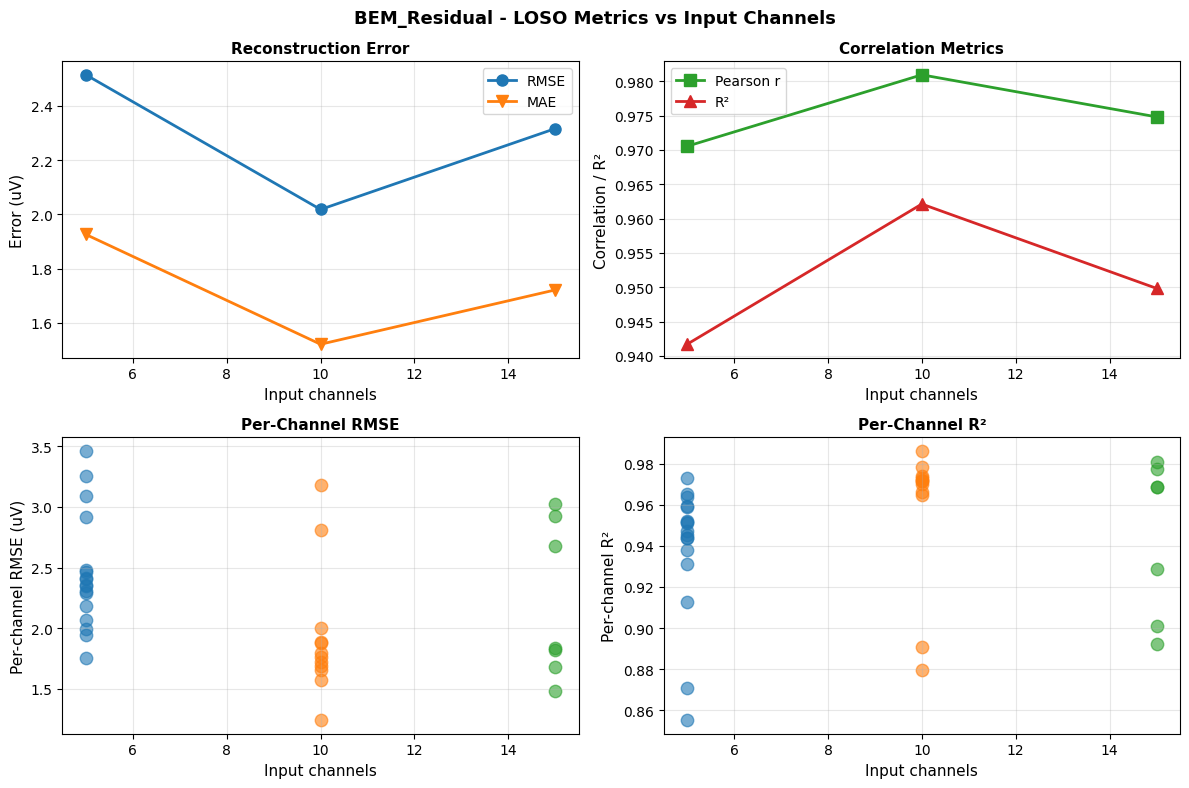

✓ Saved: C:\Users\unnat\Documents\GitHub\EEGFeatureExtraction\new_repository\Results_Visualization\BEM_Residual\bem_residual_metrics_vs_channels.png


In [8]:
# Plot metrics vs number of input channels (overall and per-channel)
fig, axes = plt.subplots(2, 2, figsize=(12, 8))

# Filter overall metrics (without 'channel' column)
overall_df_plot = metrics_df[metrics_df['channel'].isna()].copy() if 'channel' in metrics_df.columns else metrics_df
agg = overall_df_plot.groupby('n_input_channels', as_index=False)[['rmse', 'mae', 'pearson_r', 'r2']].mean()

# Plot 1: Error metrics (RMSE, MAE)
ax = axes[0, 0]
ax.plot(agg['n_input_channels'], agg['rmse'], marker='o', linewidth=2, markersize=8, color='tab:blue', label='RMSE')
ax.plot(agg['n_input_channels'], agg['mae'], marker='v', linewidth=2, markersize=8, color='tab:orange', label='MAE')
ax.set_xlabel('Input channels', fontsize=11)
ax.set_ylabel('Error (uV)', fontsize=11)
ax.set_title('Reconstruction Error', fontsize=11, fontweight='bold')
ax.grid(True, alpha=0.3)
ax.legend()

# Plot 2: Correlation metrics (Pearson r, R²)
ax = axes[0, 1]
ax.plot(agg['n_input_channels'], agg['pearson_r'], marker='s', linewidth=2, markersize=8, color='tab:green', label='Pearson r')
ax.plot(agg['n_input_channels'], agg['r2'], marker='^', linewidth=2, markersize=8, color='tab:red', label='R²')
ax.set_xlabel('Input channels', fontsize=11)
ax.set_ylabel('Correlation / R²', fontsize=11)
ax.set_title('Correlation Metrics', fontsize=11, fontweight='bold')
ax.grid(True, alpha=0.3)
ax.legend()

# Plot 3: Per-channel RMSE distribution
if 'channel' in metrics_df.columns and not per_ch_df.empty:
    ax = axes[1, 0]
    for n_ch in [5, 10, 15]:
        ch_data = per_ch_df[per_ch_df['n_input_channels'] == n_ch]
        if not ch_data.empty:
            rmse_vals = ch_data.groupby('channel')['rmse'].mean()
            ax.scatter([n_ch]*len(rmse_vals), rmse_vals, s=80, alpha=0.6, label=f'{n_ch}ch')
    ax.set_xlabel('Input channels', fontsize=11)
    ax.set_ylabel('Per-channel RMSE (uV)', fontsize=11)
    ax.set_title('Per-Channel RMSE', fontsize=11, fontweight='bold')
    ax.grid(True, alpha=0.3)
else:
    axes[1, 0].text(0.5, 0.5, 'No per-channel data', ha='center', va='center')

# Plot 4: Per-channel R² distribution
if 'channel' in metrics_df.columns and not per_ch_df.empty:
    ax = axes[1, 1]
    for n_ch in [5, 10, 15]:
        ch_data = per_ch_df[per_ch_df['n_input_channels'] == n_ch]
        if not ch_data.empty:
            r2_vals = ch_data.groupby('channel')['r2'].mean()
            ax.scatter([n_ch]*len(r2_vals), r2_vals, s=80, alpha=0.6, label=f'{n_ch}ch')
    ax.set_xlabel('Input channels', fontsize=11)
    ax.set_ylabel('Per-channel R²', fontsize=11)
    ax.set_title('Per-Channel R²', fontsize=11, fontweight='bold')
    ax.grid(True, alpha=0.3)
else:
    axes[1, 1].text(0.5, 0.5, 'No per-channel data', ha='center', va='center')

fig.suptitle(f'{METHOD_TITLE} - LOSO Metrics vs Input Channels', fontsize=13, fontweight='bold')
fig.tight_layout()
out_p = VIZ_DIR / f'{METHOD_NAME}_metrics_vs_channels.png'
fig.savefig(out_p, dpi=150, bbox_inches='tight')
plt.show()
print(f'✓ Saved: {out_p}')



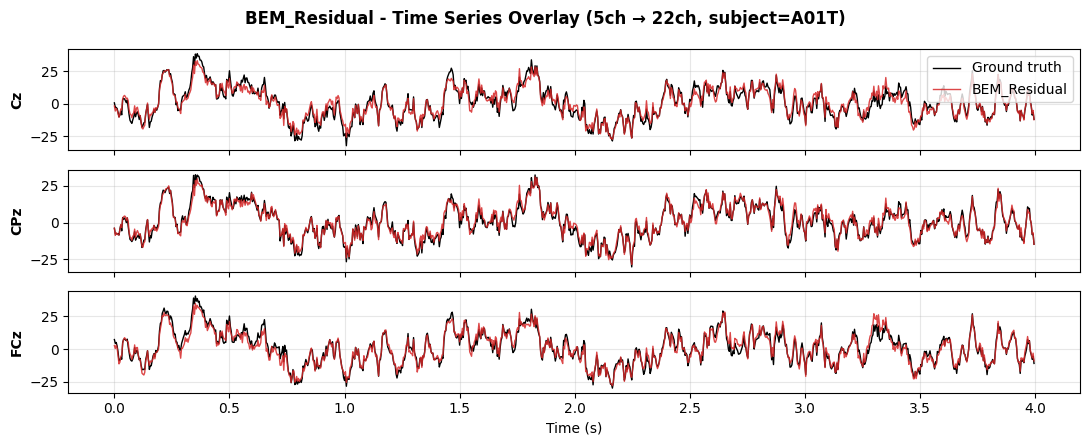

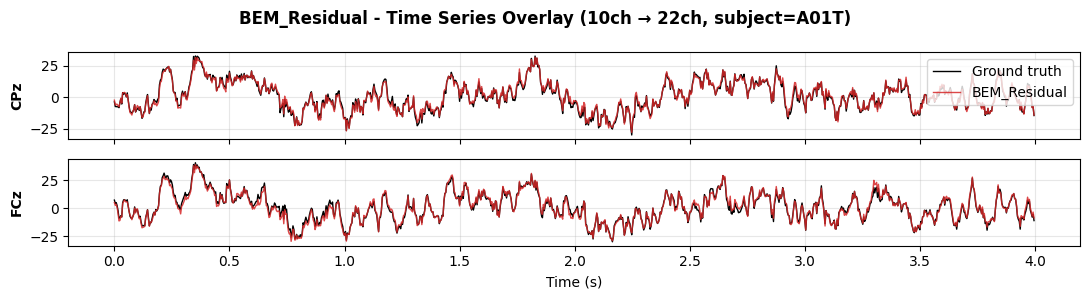

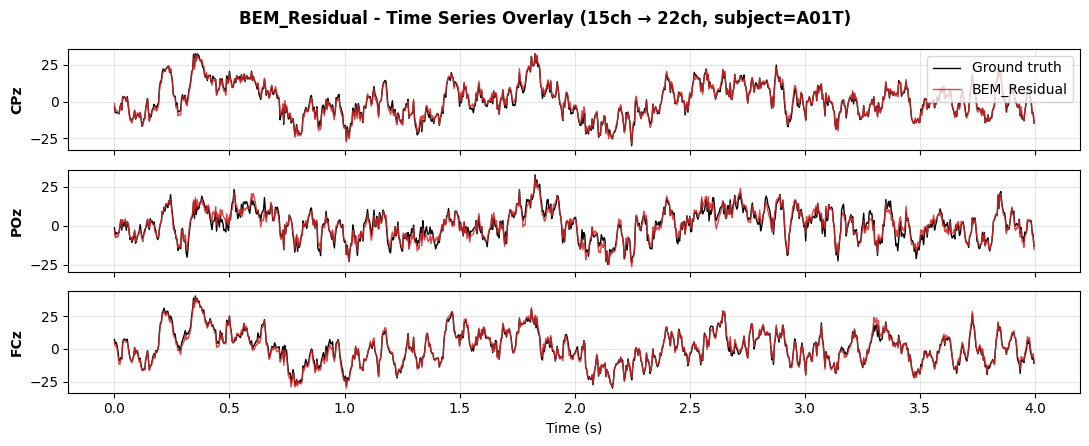

In [9]:
for n_in in [5, 10, 15]:
    if 'viz_payloads' not in locals() or n_in not in viz_payloads: continue
    
    viz_payload = viz_payloads[n_in]
    n_times, miss = viz_payload['n_times'], viz_payload['missing_channels']
    yt, yp = viz_payload['y_true_trial'], viz_payload['y_pred_trial']
    
    central_channels = ['Cz', 'C3', 'CPz', 'Pz', 'C4', 'POz', 'FCz', 'Fz']
    show_channels = [c for c in central_channels if c in miss][:6]
    if not show_channels: show_channels = miss[:6]
    
    times = np.arange(n_times) / SFREQ
    fig, axes = plt.subplots(len(show_channels), 1, figsize=(11, 1.5 * len(show_channels)), sharex=True)
    if len(show_channels) == 1: axes = [axes]
    
    for ax, ch in zip(axes, show_channels):
        idx = miss.index(ch)
        ax.plot(times, yt[:, idx], color='black', linewidth=1.0, label='Ground truth')
        ax.plot(times, yp[:, idx], color='tab:red', linewidth=1.0, alpha=0.85, label=METHOD_TITLE)
        ax.set_ylabel(ch, fontsize=10, fontweight='bold')
        ax.grid(True, alpha=0.3)
    
    axes[0].legend(loc='upper right', fontsize=10)
    axes[-1].set_xlabel('Time (s)', fontsize=10)
    fig.suptitle(f'{METHOD_TITLE} - Time Series Overlay ({n_in}ch → 22ch, subject={viz_payload["test_subject"]})', fontsize=12, fontweight='bold')
    fig.tight_layout()
    out_p = VIZ_DIR / f'{METHOD_NAME}_{n_in}ch_timeseries_overlay.png'
    fig.savefig(out_p, dpi=150, bbox_inches='tight')
    plt.show()



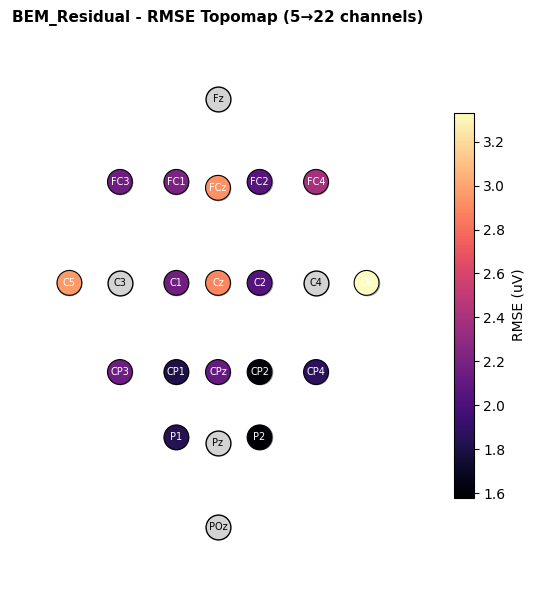

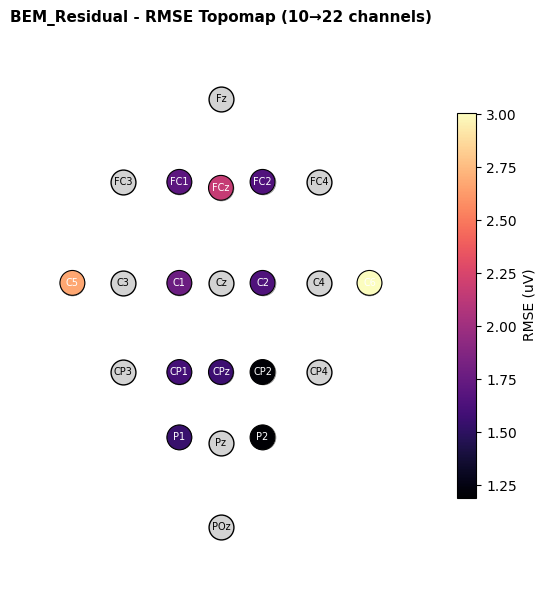

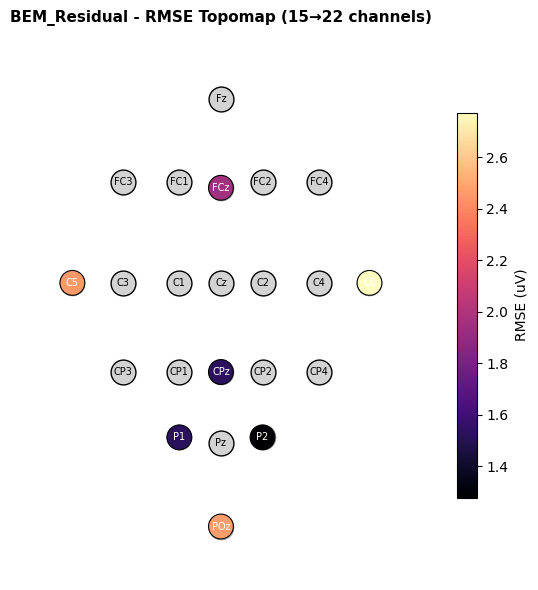

In [10]:
for n_in in sorted(viz_payloads.keys()) if 'viz_payloads' in locals() else []:
    viz_payload = viz_payloads[n_in]
    Y_true, Y_pred = viz_payload['Y_true_all'], viz_payload['Y_pred_all']
    miss, inp = viz_payload['missing_channels'], viz_payload['input_channels']
    
    rmse_per_ch = np.sqrt(np.mean((Y_true - Y_pred) ** 2, axis=0))
    fig, ax = plt.subplots(figsize=(6, 6))
    
    for ch in CHANNELS_22:
        x, y = CHANNEL_POS_2D[ch]
        if ch in inp:
            ax.scatter(x, y, c='lightgray', s=320, edgecolors='k', linewidths=1.0, zorder=2)
            ax.text(x, y, ch, ha='center', va='center', fontsize=7, zorder=3)
        else:
            ax.scatter(x, y, c='white', s=320, edgecolors='gray', linewidths=0.5, zorder=2)
    
    sc = ax.scatter([CHANNEL_POS_2D[c][0] for c in miss], [CHANNEL_POS_2D[c][1] for c in miss],
                    c=rmse_per_ch, cmap='magma', s=320, edgecolors='k', linewidths=0.8, zorder=4)
    
    for ch in miss:
        x, y = CHANNEL_POS_2D[ch]
        ax.text(x, y, ch, ha='center', va='center', fontsize=7, color='white', zorder=5)
    
    plt.colorbar(sc, ax=ax, shrink=0.7, label='RMSE (uV)')
    ax.set_xlim(-0.7, 0.7); ax.set_ylim(-1.0, 0.85); ax.set_aspect('equal'); ax.axis('off')
    ax.set_title(f'{METHOD_TITLE} - RMSE Topomap ({n_in}→22 channels)', fontsize=11, fontweight='bold')
    
    fig.tight_layout()
    out_p = VIZ_DIR / f'{METHOD_NAME}_{n_in}ch_rmse_topomap.png'
    fig.savefig(out_p, dpi=150, bbox_inches='tight')
    plt.show()



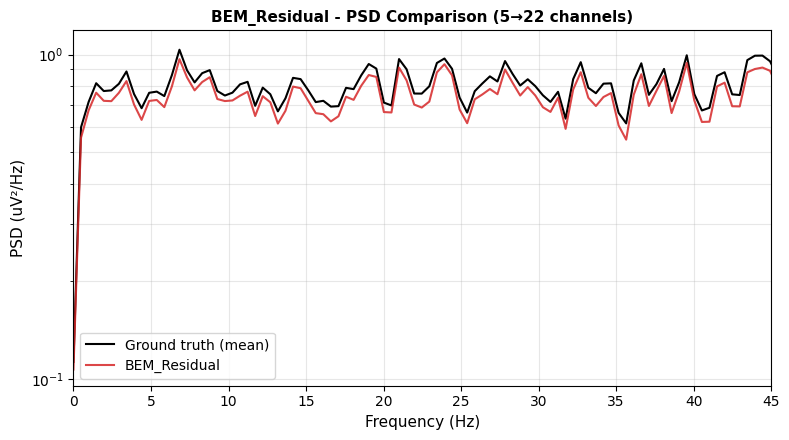

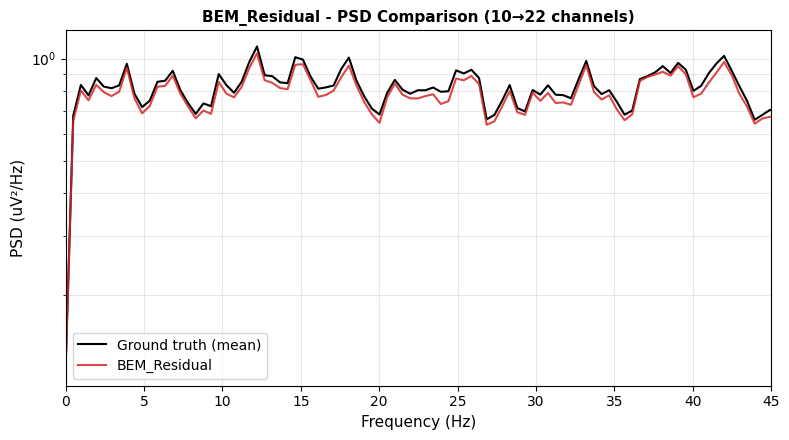

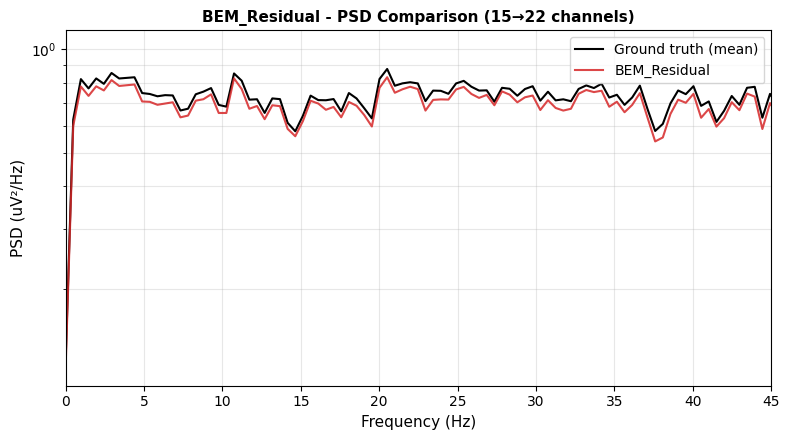

In [11]:
for n_in in sorted(viz_payloads.keys()) if 'viz_payloads' in locals() else []:
    viz_payload = viz_payloads[n_in]
    Y_true, Y_pred = viz_payload['Y_true_all'], viz_payload['Y_pred_all']
    
    nperseg = min(512, Y_true.shape[0])
    freqs, psd_t = welch(Y_true.T, fs=SFREQ, nperseg=nperseg, axis=1)
    _, psd_p = welch(Y_pred.T, fs=SFREQ, nperseg=nperseg, axis=1)
    
    fig, ax = plt.subplots(figsize=(8, 4.5))
    ax.semilogy(freqs, psd_t.mean(axis=0), color='black', linewidth=1.5, label='Ground truth (mean)')
    ax.semilogy(freqs, psd_p.mean(axis=0), color='tab:red', linewidth=1.5, alpha=0.85, label=METHOD_TITLE)
    ax.set_xlim(0, 45); ax.set_xlabel('Frequency (Hz)', fontsize=11); ax.set_ylabel('PSD (uV²/Hz)', fontsize=11)
    ax.set_title(f'{METHOD_TITLE} - PSD Comparison ({n_in}→22 channels)', fontsize=11, fontweight='bold')
    ax.grid(True, which='both', alpha=0.3)
    ax.legend(fontsize=10)
    
    fig.tight_layout()
    out_p = VIZ_DIR / f'{METHOD_NAME}_{n_in}ch_psd_comparison.png'
    fig.savefig(out_p, dpi=150, bbox_inches='tight')
    plt.show()

